In [1]:
import tensorflow as tf
from tensorflow.keras import layers, models
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from matplotlib import font_manager, rc
plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False

In [2]:
# 2. MNIST 데이터셋 불러오기

(x_train, y_train), (x_test, y_test) = tf.keras.datasets.cifar10.load_data()

In [3]:
# 3. 데이터 전처리

# x_train.shape,y_train.shape
x_train = x_train / 255.0 # 픽셀값이 0~255이기 때문에 0~1 범위로 정규화 수행
x_test = x_test / 255.0

In [43]:
data_augmentation = tf.keras.Sequential([
    layers.RandomFlip('horizontal'),
    layers.RandomRotation(0.1),
    layers.RandomZoom(0.1)
])

In [20]:
model = models.Sequential([
    # 첫 번째 합성곱 
    layers.Conv2D(32, (3, 3), padding='same',activation='relu', input_shape=(32, 32, 3)),
    layers.BatchNormalization(),
    layers.Conv2D(32, (3, 3), padding='same',activation='relu'),
    layers.MaxPooling2D((2, 2)), 
    layers.Dropout(0.2), 

    # 두 번째 합성곱 
    layers.Conv2D(64, (3, 3),padding='same', activation='relu'),
    layers.BatchNormalization(),
    layers.Conv2D(64, (3, 3),padding='same', activation='relu'),
    layers.MaxPooling2D((2, 2)),
    layers.Dropout(0.3), 
    
    layers.Flatten(),          
    layers.Dense(512, activation='relu'),
    layers.Dropout(0.5),

    layers.Dense(10, activation='softmax')
])


In [21]:
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

In [22]:
history = model.fit(
    x_train,y_train,
    epochs=10,
    batch_size=64,
    validation_split=0.2,
    verbose=1
)

Epoch 1/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 61s 94ms/step - accuracy: 0.3643 - loss: 1.7685 - val_accuracy: 0.5038 - val_loss: 1.3740
Epoch 2/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 58s 93ms/step - accuracy: 0.5061 - loss: 1.3637 - val_accuracy: 0.6226 - val_loss: 1.0665
Epoch 3/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 56s 90ms/step - accuracy: 0.5854 - loss: 1.1707 - val_accuracy: 0.6471 - val_loss: 0.9971
Epoch 4/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 57s 91ms/step - accuracy: 0.6342 - loss: 1.0468 - val_accuracy: 0.6688 - val_loss: 0.9374
Epoch 5/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 56s 90ms/step - accuracy: 0.6663 - loss: 0.9562 - val_accuracy: 0.7108 - val_loss: 0.8244
Epoch 6/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 59s 94ms/step - accuracy: 0.6920 - loss: 0.8890 - val_accuracy: 0.7221 - val_loss: 0.8118
Epoch 7/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 57s 91ms/step - accuracy: 0.7127 - loss: 0.8313 - val_accuracy: 0.7541 - val_loss: 0.7160
Epoch 8/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 58s 93ms/step - accuracy: 0.7308 - loss: 0.7790 - 

In [23]:
test_loss, test_acc = model.evaluate(x_test, y_test, verbose=0)
print(f"Fashion MNIST 테스트 정확도: {test_acc:.4f}")
print(f"Fashion MNISH 테스트 손실값: {test_loss:.4f}")

Fashion MNIST 테스트 정확도: 0.7449
Fashion MNISH 테스트 손실값: 0.7642


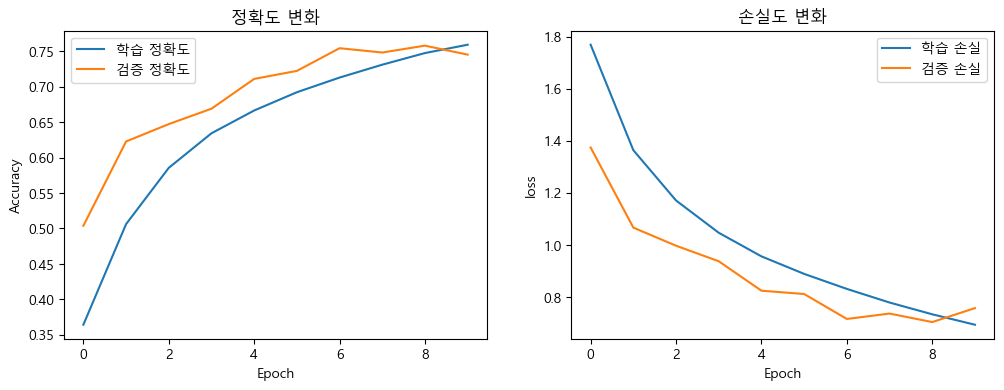

In [24]:
plt.figure(figsize=(12,4))

# 정확도 그래프
plt.subplot(1,2,1)
plt.plot(history.history['accuracy'], label='학습 정확도')
plt.plot(history.history['val_accuracy'], label='검증 정확도')
plt.title("정확도 변화")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
 
# 손실 그래프
plt.subplot(1,2,2)
plt.plot(history.history['loss'], label='학습 손실')
plt.plot(history.history['val_loss'], label='검증 손실')
plt.title("손실도 변화")
plt.xlabel("Epoch")
plt.ylabel("loss")
plt.legend()
plt.show()

In [37]:
# 예측 수행

predictions = model.predict(x_test)             # 테스트 데이터 전체에 대한 예측 결과(확률값) 생성
pred_labels = np.argmax(predictions, axis=1)    
# 클래스 확률값 중에서 가장 높은 확률을 가진 클래스를 선택 (가장 높은 확률 클래스 1치환, 나머지는 0으로 치환)



313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step


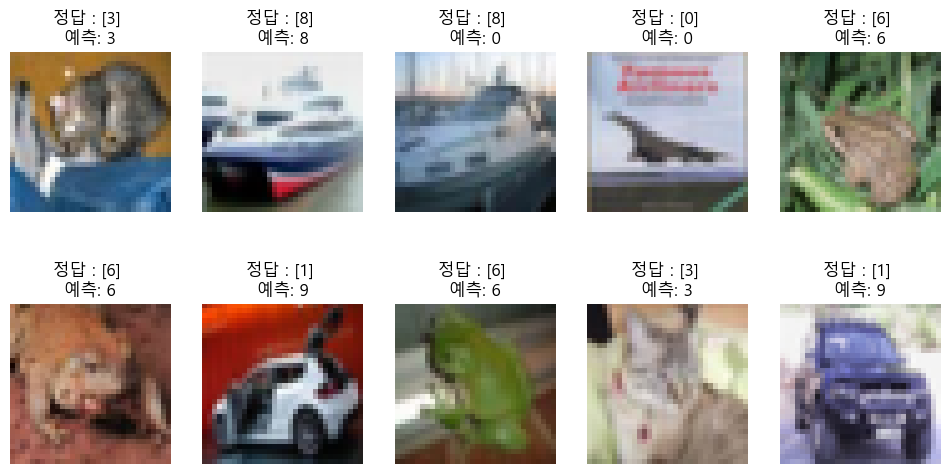

In [40]:
plt.figure(figsize=(12,6))

for i in range(10):
    plt.subplot(2,5,i+1)
    plt.imshow(x_test[i].reshape(32,32,3), cmap='gray')
    plt.title(f"정답 : {y_test[i]} \n예측: {pred_labels[i]}")
    plt.axis("off")
    #plt.suptitle("MNIST 이미지 예측 결과", fontsize=16)
    
plt.show()

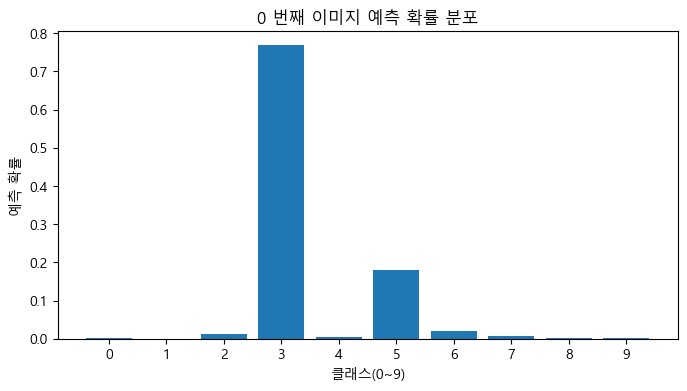

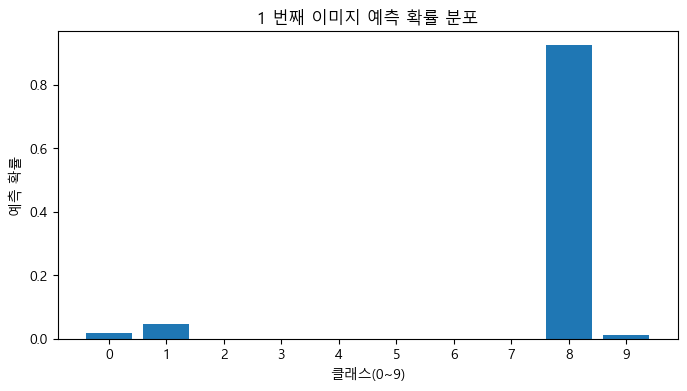

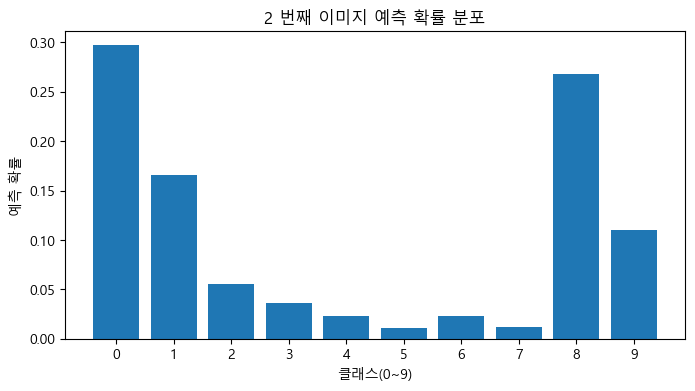

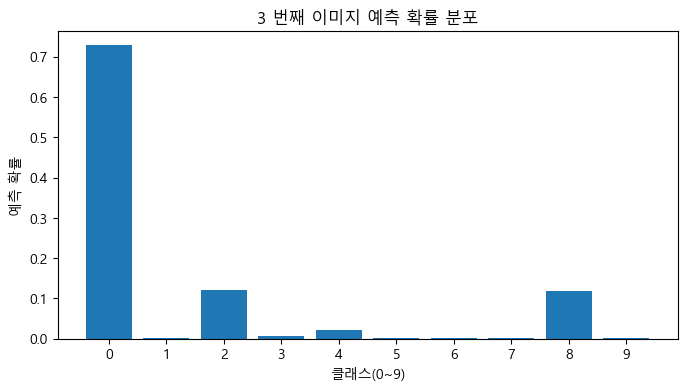

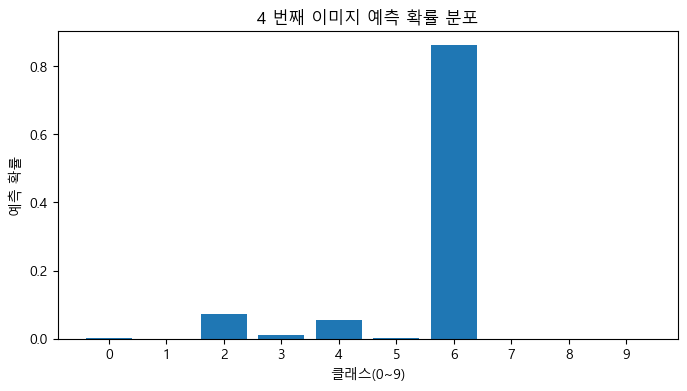

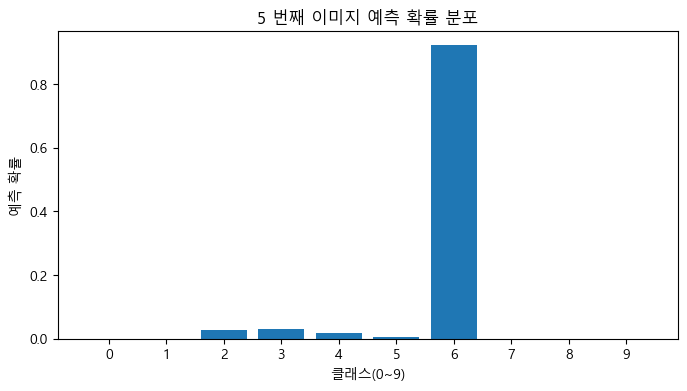

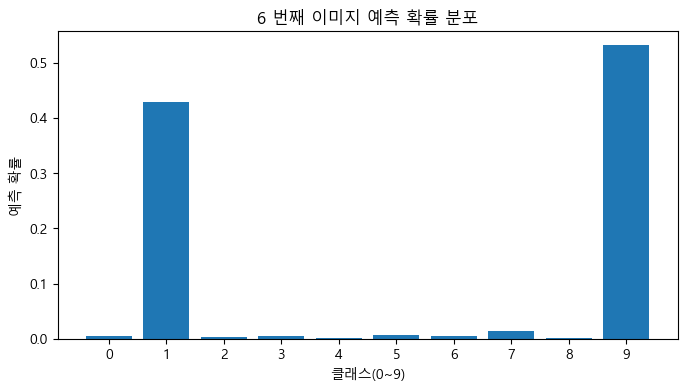

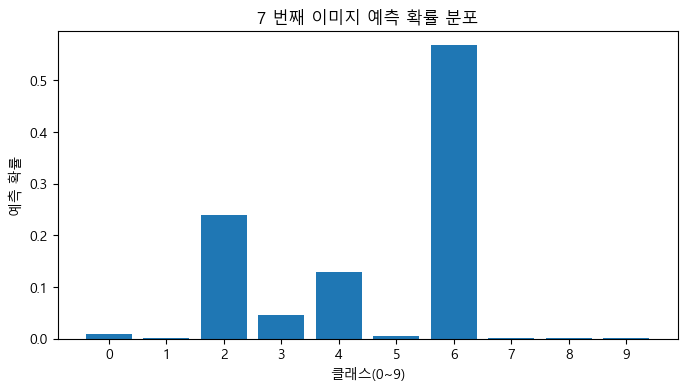

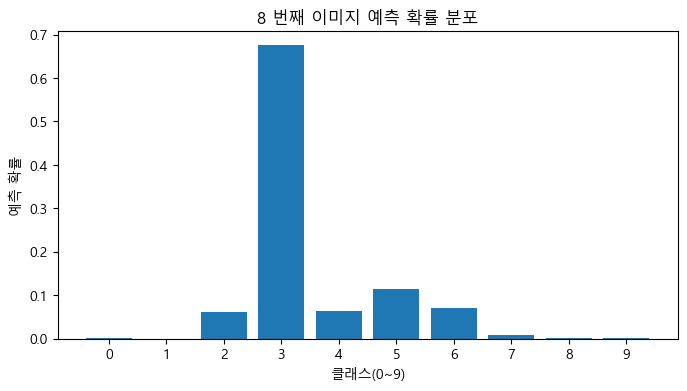

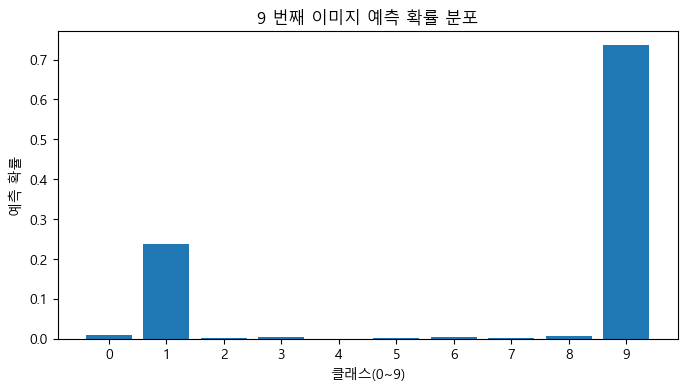

In [41]:
for i in range(10):
    plt.figure(figsize=(8,4))
    plt.bar(range(10), predictions[i])
    plt.xticks(range(10))
    plt.xlabel("클래스(0~9)")
    plt.ylabel("예측 확률")
    plt.title("{} 번째 이미지 예측 확률 분포".format(i))
plt.show()